In [3]:
import pandas as pd
candy = pd.read_csv('../data/candy-data-cleaned.csv')

We will first fit baseline OLS model, only with the original features, to have a benchmark for later more complex models. A new feature, 'mother_company' will add quite a lot of complexity to the model.

In [4]:
# model winpercent by ols on all other features except for combination and competitorname
import statsmodels.api as sm
X = candy.drop(columns=['winpercent', 'competitorname', 'mother_company', 'big_brand'])
y = candy['winpercent']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             winpercent   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.471
Method:                 Least Squares   F-statistic:                     7.791
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           9.64e-09
Time:                        03:10:21   Log-Likelihood:                 75.756
No. Observations:                  85   AIC:                            -127.5
Df Residuals:                      73   BIC:                            -98.20
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3889      0.046      8.493      0.000       0.298       0.480
chocolate            0.1976      0.039      5.066      0.000       0.120       0.275
fruity               0.0942      0.038      2.502      0.015       0.019       0.169
caramel              0.0221      0.037      0.605      0.547      -0.051       0.095
peanutyalmondy       0.1006      0.036      2.781      0.007       0.029       0.173
nougat               0.0082      0.057      0.143      0.887      -0.106       0.122
crispedricewafer     0.0892      0.053      1.693      0.095      -0.016       0.194
hard                -0.0616      0.035     -1.782      0.079      -0.131       0.007
bar                  0.0043      0.051      0.085      0.933      -0.097       0.105
pluribus            -0.0086      0.030     -0.284      0.777      -0.069       0.052
sugarpercent         0.0256      0.013      1.953      0.055      -0.001       0.052
pricepercent        -0.0594      0.055     -1.077      0.285      -0.169       0.051
==============================================================================
Omnibus:                        1.037   Durbin-Watson:                   1.728
Prob(Omnibus):                  0.596   Jarque-Bera (JB):                1.009
Skew:                          -0.105   Prob(JB):                        0.604
Kurtosis:                       2.510   Cond. No.                         9.45
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [5]:
# Ensure 'mother_company' is categorical with 'Unknown' as the first category
candy['mother_company'] = pd.Categorical(
    candy['mother_company'],
    categories=['Unknown'] + [cat for cat in candy['mother_company'].unique() if cat != 'Unknown']
)


In [6]:
dummies = pd.get_dummies(candy['mother_company'], drop_first=True, dtype=int)
X = pd.concat([candy, dummies], axis=1).drop(columns=['winpercent', 'competitorname', 'mother_company'])
y = pd.concat([candy, dummies], axis=1)['winpercent']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             winpercent   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.579
Method:                 Least Squares   F-statistic:                     5.134
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           1.01e-07
Time:                        03:10:21   Log-Likelihood:                 96.800
No. Observations:                  85   AIC:                            -135.6
Df Residuals:                      56   BIC:                            -64.76
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                       0.4025      0.058      6.916      0.000       0.286       0.519
chocolate                                   0.1982      0.043      4.632      0.000       0.113       0.284
fruity                                      0.0813      0.044      1.857      0.069      -0.006       0.169
caramel                                     0.0126      0.036      0.348      0.729      -0.060       0.085
peanutyalmondy                              0.0637      0.034      1.859      0.068      -0.005       0.132
nougat                                     -0.0031      0.053     -0.058      0.954      -0.109       0.103
crispedricewafer                            0.0643      0.049      1.320      0.192      -0.033       0.162
hard                                       -0.0424      0.045     -0.942      0.350      -0.133       0.048
bar                                        -0.0252      0.048     -0.521      0.605      -0.122       0.072
pluribus                                   -0.0271      0.033     -0.828      0.411      -0.093       0.038
sugarpercent                                0.0265      0.014      1.886      0.065      -0.002       0.055
pricepercent                               -0.0918      0.060     -1.524      0.133      -0.212       0.029
big_brand                                   0.0416      0.055      0.753      0.455      -0.069       0.152
Ferrero SpA                                -0.0570      0.028     -2.026      0.048      -0.113      -0.001
Mars, Inc.                                  0.0804      0.033      2.455      0.017       0.015       0.146
Perfetti Van Melle                          0.0458      0.123      0.372      0.712      -0.201       0.293
Hershey's                                   0.0231      0.031      0.750      0.457      -0.039       0.085
Tootsie Roll Industries                    -0.1070      0.030     -3.592      0.001      -0.167      -0.047
Mondelez International                      0.0387      0.049      0.785      0.436      -0.060       0.138
Spangler Candy Company                     -0.0671      0.114     -0.590      0.558      -0.295       0.161
Haribo                                      0.0283      0.047      0.606      0.547      -0.065       0.122
Nestlé                                      0.0350      0.040      0.868      0.389      -0.046       0.116
Just Born                                4.384e-05      0.122      0.000      1.000      -0.245       0.245
Zeta Espacial S.A.                          0.0638      0.119      0.537      0.593      -0.174       0.302
American Licorice Company                  -0.0827      0.120     -0.688      0.495      -0.323       0.158
Topps                                      -0.0236      0.1

In [7]:
# model winpercent on mother_company only
import statsmodels.api as sm
X = pd.get_dummies(candy['mother_company'], drop_first=True, dtype=int)
y = candy['winpercent']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             winpercent   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     4.275
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           8.94e-06
Time:                        03:10:21   Log-Likelihood:                 73.974
No. Observations:                  85   AIC:                            -111.9
Df Residuals:                      67   BIC:                            -67.98
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
const                                       0.3567      0.057      6.251      0.000       0.243       0.471
Ferrero SpA                                 0.0619      0.064      0.964      0.339      -0.066       0.190
Mars, Inc.                                  0.3071      0.065      4.745      0.000       0.178       0.436
Perfetti Van Melle                          0.1663      0.128      1.303      0.197      -0.088       0.421
Hershey's                                   0.2436      0.064      3.817      0.000       0.116       0.371
Tootsie Roll Industries                     0.0529      0.066      0.803      0.425      -0.079       0.184
Mondelez International                      0.1235      0.081      1.530      0.131      -0.038       0.285
Spangler Candy Company                      0.0383      0.128      0.300      0.765      -0.216       0.293
Haribo                                      0.1055      0.081      1.307      0.196      -0.056       0.267
Nestlé                                      0.2026      0.074      2.749      0.008       0.056       0.350
Just Born                                   0.1073      0.128      0.840      0.404      -0.147       0.362
Zeta Espacial S.A.                          0.0563      0.128      0.441      0.661      -0.198       0.311
American Licorice Company                   0.0163      0.128      0.127      0.899      -0.238       0.271
Topps                                      -0.0037      0.128     -0.029      0.977      -0.258       0.251
SweetWorks Confections                     -0.0097      0.128     -0.076      0.939      -0.264       0.245
Impact Confections                          0.0333      0.128      0.261      0.795      -0.221       0.288
The Promotion In Motion Companies, Inc.     0.0873      0.128      0.684      0.497      -0.167       0.342
August Storck KG                            0.0623      0.128      0.488      0.627      -0.192       0.317
==============================================================================
Omnibus:                        0.673   Durbin-Watson:                   1.653
Prob(Omnibus):                  0.714   Jarque-Bera (JB):                0.581
Skew:                           0.199   Prob(JB):                        0.748
Kurtosis:                       2.926   Cond. No.                         22.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
#ols model with original features + big brand
X = candy.drop(columns=['winpercent', 'competitorname', 'mother_company'])
y = candy['winpercent']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             winpercent   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     7.119
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           2.33e-08
Time:                        03:10:21   Log-Likelihood:                 75.999
No. Observations:                  85   AIC:                            -126.0
Df Residuals:                      72   BIC:                            -94.24
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3777      0.049      7.677      0.000       0.280       0.476
chocolate            0.1918      0.040      4.768      0.000       0.112       0.272
fruity               0.0887      0.039      2.289      0.025       0.011       0.166
caramel              0.0202      0.037      0.549      0.585      -0.053       0.094
peanutyalmondy       0.0979      0.037      2.679      0.009       0.025       0.171
nougat               0.0076      0.057      0.133      0.895      -0.107       0.122
crispedricewafer     0.0889      0.053      1.681      0.097      -0.017       0.194
hard                -0.0551      0.036     -1.525      0.132      -0.127       0.017
bar                  0.0009      0.051      0.018      0.985      -0.101       0.103
pluribus            -0.0123      0.031     -0.395      0.694      -0.074       0.050
sugarpercent         0.0261      0.013      1.981      0.051      -0.000       0.052
pricepercent        -0.0614      0.055     -1.107      0.272      -0.172       0.049
big_brand            0.0235      0.036      0.643      0.522      -0.049       0.096
==============================================================================
Omnibus:                        1.144   Durbin-Watson:                   1.669
Prob(Omnibus):                  0.564   Jarque-Bera (JB):                1.071
Skew:                          -0.107   Prob(JB):                        0.585
Kurtosis:                       2.494   Cond. No.                         11.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
candy

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent,mother_company,big_brand
0,100 Grand,1,0,1,0,0,1,0,1,0,0.901261,0.860,0.670,Ferrero SpA,1
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.445922,0.511,0.676,"Mars, Inc.",1
2,One dime,0,0,0,0,0,0,0,0,0,-1.663576,0.116,0.323,Unknown,0
3,One quarter,0,0,0,0,0,0,0,0,0,-1.663576,0.511,0.461,Unknown,0
4,Air Heads,0,1,0,0,0,0,0,0,0,1.520236,0.511,0.523,Perfetti Van Melle,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,1,0,0,0,0,0,0,0,-0.920093,0.116,0.455,Hershey's,1
81,Warheads,0,1,0,0,0,0,1,0,0,-1.371875,0.116,0.390,Impact Confections,0
82,Welch's Fruit Snacks,0,1,0,0,0,0,0,0,1,-0.589262,0.313,0.444,"The Promotion In Motion Companies, Inc.",0
83,Werther's Original Caramel,0,0,1,0,0,0,1,0,0,-1.041043,0.267,0.419,August Storck KG,0


In [10]:
# use cross-validation and get rmse
# for further comparison with more advanced models
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

TO_DROP = ['competitorname', 'mother_company']
X = candy.drop(columns=TO_DROP + ['winpercent'])
y = candy['winpercent']
model = LinearRegression()
neg_mse_scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)
rmse_scores = np.sqrt(-neg_mse_scores)
print('RMSE scores:', rmse_scores)
print('Mean RMSE:', rmse_scores.mean())


RMSE scores: [0.14353577 0.08052761 0.08969202 0.15398449 0.14949008]
Mean RMSE: 0.12344599633586717


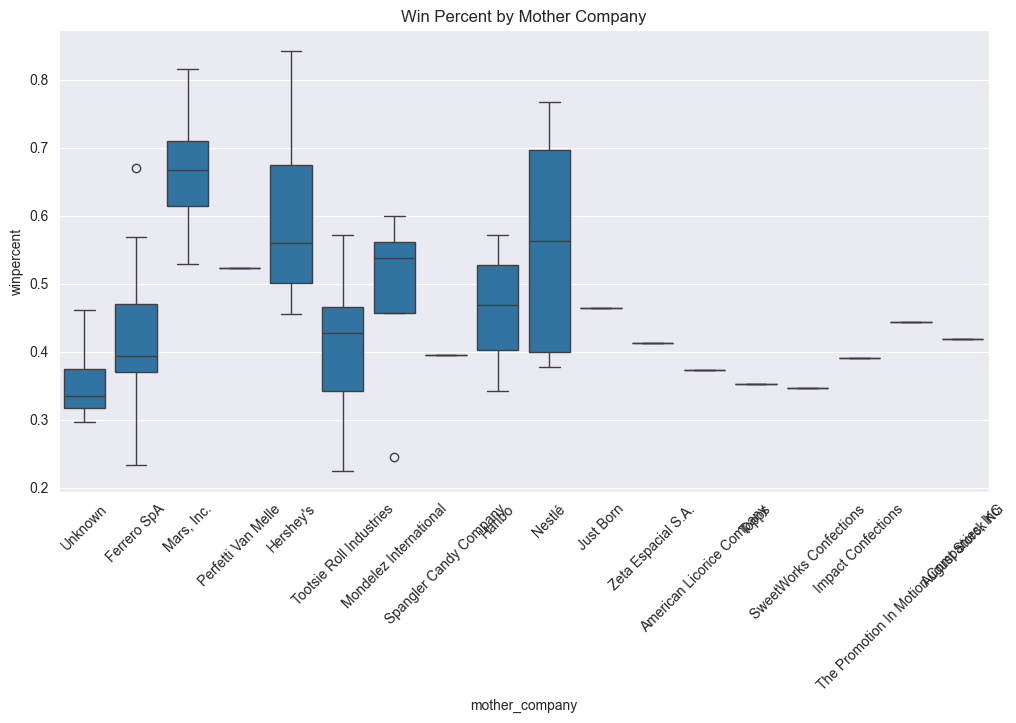

In [11]:
# box plots of winpercent by mother company
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x='mother_company', y='winpercent', data=candy)
plt.xticks(rotation=45)
plt.title('Win Percent by Mother Company')
plt.show()



In [12]:
#test normality inside mother companies
import scipy.stats as stats
grouped = candy.groupby('mother_company')['winpercent']
normality_results = {}
for name, group in grouped:
    _, p_value = stats.shapiro(group)
    normality_results[name] = p_value
normality_results
# statistical test shows that all the groups which have enough samples to test for normality are normally distributed (we cannot reject 0 hypothesis of normality)

/var/folders/3r/pv_sqnpd6bb8wr1nhrml1snw0000gq/T/ipykernel_94500/3644028511.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = candy.groupby('mother_company')['winpercent']
/var/folders/3r/pv_sqnpd6bb8wr1nhrml1snw0000gq/T/ipykernel_94500/3644028511.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p_value = stats.shapiro(group)


{'Unknown': np.float64(0.2801109930421233),
 'Ferrero SpA': np.float64(0.6678669754802811),
 'Mars, Inc.': np.float64(0.9994874430347255),
 'Perfetti Van Melle': np.float64(nan),
 "Hershey's": np.float64(0.10269976968225898),
 'Tootsie Roll Industries': np.float64(0.9850405881413508),
 'Mondelez International': np.float64(0.09630522369164717),
 'Spangler Candy Company': np.float64(nan),
 'Haribo': np.float64(0.8722512064132544),
 'Nestlé': np.float64(0.18660705070906797),
 'Just Born': np.float64(nan),
 'Zeta Espacial S.A.': np.float64(nan),
 'American Licorice Company': np.float64(nan),
 'Topps': np.float64(nan),
 'SweetWorks Confections': np.float64(nan),
 'Impact Confections': np.float64(nan),
 'The Promotion In Motion Companies, Inc.': np.float64(nan),
 'August Storck KG': np.float64(nan)}

In [13]:
# filter only those results where p-value is not nan
normality_results_filtered = {name: p_value for name, p_value in normality_results.items() if not np.isnan(p_value)}

In [14]:
# filter only companies where normality was not rejected
candy_normal = candy[candy['mother_company'].isin([name for name, p_value in normality_results_filtered.items() if p_value > 0.05])]
candy_normal.loc[:, 'mother_company'] = candy_normal['mother_company'].cat.remove_unused_categories()


/var/folders/3r/pv_sqnpd6bb8wr1nhrml1snw0000gq/T/ipykernel_94500/3863558858.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Ferrero SpA', 'Mars, Inc.', 'Unknown', 'Unknown', 'Hershey's', ..., 'Tootsie Roll Industries', 'Ferrero SpA', 'Mars, Inc.', 'Hershey's', 'Hershey's']
Length: 75
Categories (8, object): ['Unknown', 'Ferrero SpA', 'Mars, Inc.', 'Hershey's', 'Tootsie Roll Industries', 'Mondelez International', 'Haribo', 'Nestlé']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  candy_normal.loc[:, 'mother_company'] = candy_normal['mother_company'].cat.remove_unused_categories()


In [16]:
# test hypothesis that the mean winpercent is the same across all mother companies using ANOVA
# use only companies where we could test normality (big enough sample size)

groups = [group['winpercent'].values for name, group in candy_normal.groupby('mother_company')]
anova_result = stats.f_oneway(*groups)
print('ANOVA result:', anova_result)

ANOVA result: F_onewayResult(statistic=np.float64(9.066122609027872), pvalue=np.float64(7.976577982755758e-08))


/var/folders/3r/pv_sqnpd6bb8wr1nhrml1snw0000gq/T/ipykernel_94500/2671153827.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['winpercent'].values for name, group in candy_normal.groupby('mother_company')]


In [17]:
# we reject the null hypthesis, the group means are different

In [18]:
# take top for mother companies by number of candy brands
top_companies = candy['mother_company'].value_counts().nlargest(4).index.tolist()
candy_top = candy[candy['mother_company'].isin(top_companies)]

In [19]:
import scipy.stats as stats
groups = [group['winpercent'].values for name, group in candy_top.groupby('mother_company')]
anova_result = stats.f_oneway(*groups)
print('ANOVA result:', anova_result)

ANOVA result: F_onewayResult(statistic=np.float64(nan), pvalue=np.float64(nan))


/var/folders/3r/pv_sqnpd6bb8wr1nhrml1snw0000gq/T/ipykernel_94500/480086901.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['winpercent'].values for name, group in candy_top.groupby('mother_company')]
/var/folders/3r/pv_sqnpd6bb8wr1nhrml1snw0000gq/T/ipykernel_94500/480086901.py:3: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  anova_result = stats.f_oneway(*groups)


In [20]:
candy_top.mother_company

0                 Ferrero SpA
1                  Mars, Inc.
5                   Hershey's
6                 Ferrero SpA
7                 Ferrero SpA
8                 Ferrero SpA
9     Tootsie Roll Industries
10    Tootsie Roll Industries
11                Ferrero SpA
13    Tootsie Roll Industries
15    Tootsie Roll Industries
16                Ferrero SpA
17                Ferrero SpA
22                  Hershey's
23                  Hershey's
24                  Hershey's
25                  Hershey's
26                Ferrero SpA
27    Tootsie Roll Industries
29                Ferrero SpA
30                Ferrero SpA
31                 Mars, Inc.
32                 Mars, Inc.
33                 Mars, Inc.
35                  Hershey's
36                 Mars, Inc.
37                 Mars, Inc.
38                 Mars, Inc.
39                  Hershey's
40                  Hershey's
41                Ferrero SpA
44    Tootsie Roll Industries
45                Ferrero SpA
46        

In [21]:
candy.loc[candy['mother_company'] == "Hershey's", ['competitorname', 'mother_company']]

,competitorname,mother_company
5,Almond Joy,Hershey's
22,Hershey's Kisses,Hershey's
23,Hershey's Krackel,Hershey's
24,Hershey's Milk Chocolate,Hershey's
25,Hershey's Special Dark,Hershey's
35,Milk Duds,Hershey's
39,Mounds,Hershey's
40,Mr Good Bar,Hershey's
46,Payday,Hershey's
51,Reese's Miniatures,Hershey's


### train catboost model and make it explainable

In [22]:
import pandas as pd
candy = pd.read_csv('/Users/A107809368/projects/playground/candy_case_study/data/candy-data-cleaned.csv')

In [23]:
candy.columns

Index(['competitorname', 'chocolate', 'fruity', 'caramel', 'peanutyalmondy',
       'nougat', 'crispedricewafer', 'hard', 'bar', 'pluribus', 'sugarpercent',
       'pricepercent', 'winpercent', 'mother_company', 'big_brand'],
      dtype='object')

In [24]:
from catboost import Pool, cv

CAT_FEATURES = ['chocolate', 'fruity', 'caramel', 'peanutyalmondy', 'nougat',
                'crispedricewafer', 'hard', 'bar', 'pluribus', 'mother_company']

TO_DROP = ['competitorname']
X = candy.drop(columns=TO_DROP + ['winpercent'])
y = candy['winpercent']

# Create Pool object with categorical features
pool = Pool(data=X, label=y, cat_features=CAT_FEATURES)

# Parameters WITHOUT cat_features
params = {
    'iterations': 100,
    'learning_rate': 0.05,
    'depth': 6,
    'verbose': 100,
    'loss_function': 'RMSE',
}

# Run cross-validation with Pool object
cv_results = cv(
    pool=pool,
    params=params,
    fold_count=5,
    plot=True,
    return_models=True,
)

print(cv_results)

print(cv_results[1][4].get_feature_importance(prettified=True))

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]
0:	learn: 0.5132340	test: 0.4831528	best: 0.4831528 (0)	total: 64.2ms	remaining: 6.35s
99:	learn: 0.0743453	test: 0.1035875	best: 0.1035875 (99)	total: 190ms	remaining: 0us

bestTest = 0.1035875333
bestIteration = 99

Training on fold [1/5]
0:	learn: 0.5026634	test: 0.5333405	best: 0.5333405 (0)	total: 1.88ms	remaining: 186ms
99:	learn: 0.0747912	test: 0.1141142	best: 0.1141142 (99)	total: 111ms	remaining: 0us

bestTest = 0.1141141857
bestIteration = 99

Training on fold [2/5]
0:	learn: 0.5187435	test: 0.4675697	best: 0.4675697 (0)	total: 3.87ms	remaining: 383ms
99:	learn: 0.0713696	test: 0.1029615	best: 0.1029615 (99)	total: 173ms	remaining: 0us

bestTest = 0.1029615304
bestIteration = 99

Training on fold [3/5]
0:	learn: 0.5063771	test: 0.5226656	best: 0.5226656 (0)	total: 3.14ms	remaining: 311ms
99:	learn: 0.0712546	test: 0.1544324	best: 0.1544324 (99)	total: 104ms	remaining: 0us

bestTest = 0.1544323558
bestIteration = 99

Training on fold [4/5]
0:	learn: 0.5

In [25]:
cv_results[1][4].get_feature_importance(prettified=True)

,Feature Id,Importances
0,pricepercent,20.599088
1,sugarpercent,19.079268
2,chocolate,12.312740
3,mother_company,9.845497
4,pluribus,7.892125
5,big_brand,7.661184
6,bar,6.101830
7,fruity,4.589881
8,hard,3.878502
9,peanutyalmondy,3.651243


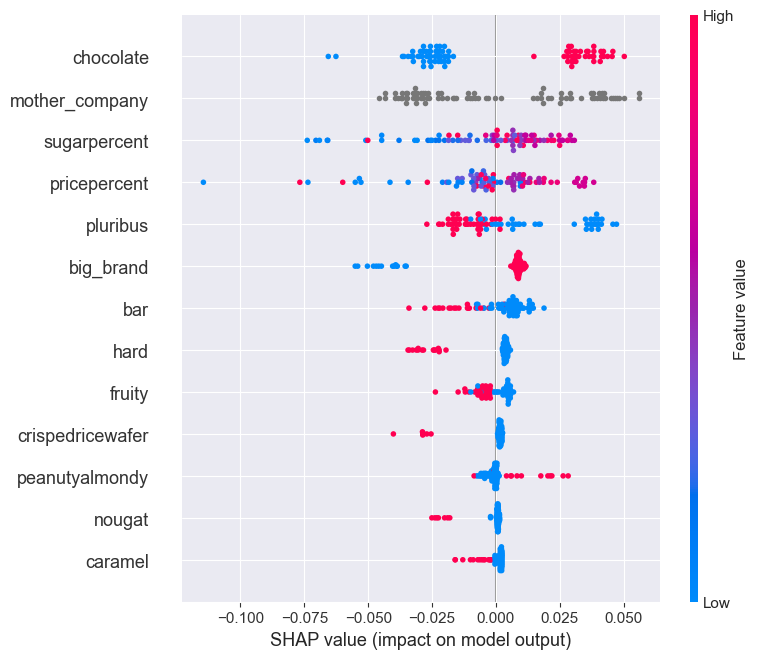

In [26]:
# get shapley values
import shap
explainer = shap.Explainer(cv_results[1][4])
shap_values = explainer(X)
# plot shapley values
shap.summary_plot(shap_values, X)